In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [103]:
words=open('names.txt', 'r').read().splitlines()
print(words[:10:])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
32033


In [104]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [299]:
#splitting the dataset intro train(80%), dev(10%),test(10%)

def build_dataset(words):
    block_size=3            #no. of elements in our context used to predict the next char 
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]        #updating last (3rd) element in context block


    X=torch.tensor(X)
    Y =torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y


import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xtest,Ytest=build_dataset(words[n2:])

torch.Size([182484, 3]) torch.Size([182484])
torch.Size([22869, 3]) torch.Size([22869])
torch.Size([22793, 3]) torch.Size([22793])


In [339]:
g=torch.Generator().manual_seed(2147483647)

#initializing 10-d embeddings for all 27 of our characters
C=torch.randn((27,15),generator=g)

#creating hyperparamters
W1=torch.randn((45,300),generator=g)
b1=torch.randn((300),generator=g)

W2=torch.randn((300,27),generator=g)
b2=torch.randn((27),generator=g)

parameters=[C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad=True    

lossarr=[]    

In [351]:
#backward pass
parameters=[C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad=True    
#training on a mini batch of the train split

for i in range(30000):
    ix=torch.randint(0,Xtr.shape[0],(50,))
    emb=C[Xtr[ix]]
    h=torch.tanh(emb.view(-1,45)@ W1 +b1)  #(100,300)
    logits=h @ W2 +b2    #(100,27)
    loss=F.cross_entropy(logits,Ytr[ix])

    #gradient descent
    for p in parameters:
        p.grad =None
    loss.backward()

    lr=  0.0001 

    for p in parameters:
        p.data+= -lr * p.grad
    lossarr.append(loss.item())
    if loss.item()<1.5:
        break 
print(loss.item())         

1.4771896600723267


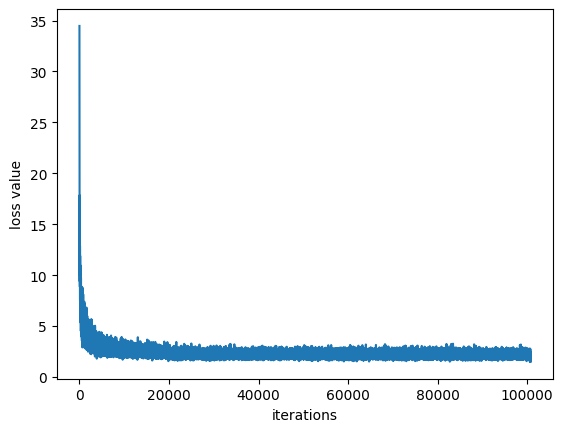

In [350]:
plt.plot(range(len(lossarr)),lossarr)
plt.xlabel("iterations")
plt.ylabel("loss value")
plt.show()

In [347]:
print(min(lossarr))

1.4845749139785767


In [353]:
for i,loss in enumerate(lossarr):
    if loss < 1.55:
        print(i,loss)

59067 1.5344996452331543
61948 1.5377284288406372
64698 1.5207782983779907
82724 1.5093863010406494
100717 1.4845749139785767
113884 1.4771896600723267


In [354]:
#loss on the dev dataset after mini batch optimization of training set
emb=C[Xdev]
h=torch.tanh(emb.view(-1,45) @ W1 +b1)
logits= h @ W2 + b2
loss=F.cross_entropy(logits,Ydev)
print(loss.item())


2.2417659759521484


In [296]:
#loss on the dev dataset after mini batch optimization of training set
emb=C[Xtest]
h=torch.tanh(emb.view(-1,30) @ W1 +b1)
logits= h @ W2 + b2
loss=F.cross_entropy(logits,Ytest)
print(loss.item())


2.3374650478363037


In [ ]:
#sampling from the model
g=torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out =[]
    context=[0]*5
    while True:
        emb=C[torch.tensor([context])]
        